In [1]:
# =====================================================
# PARTE 1: IMPORTACIONES Y CONFIGURACIÓN INICIAL
# =====================================================

import pandas as pd
import numpy as np
import pyodbc
from prophet import Prophet # esto es para realizar el forecasting
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime, timedelta
import logging

# Configurar logging para mejor debugging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Suprimir warnings innecesarios
warnings.filterwarnings('ignore', category=FutureWarning)

print("✅ Librerías importadas correctamente")
print("📊 Configuración de logging establecida")

Importing plotly failed. Interactive plots will not work.


✅ Librerías importadas correctamente
📊 Configuración de logging establecida


In [2]:
# =====================================================
# PARTE 2: CONFIGURACIÓN DE CONEXIÓN A BASE DE DATOS
# =====================================================

# CONFIGURACIÓN DE CONEXIÓN - MODIFICA ESTOS VALORES
connection_config = {
    'driver': '{ODBC Driver 18 for SQL Server}',  # O '{ODBC Driver 17 for SQL Server}'
    'server': r'HectorPc',  # 🔧 CAMBIA POR TU SERVIDOR
    'database': 'data_bi'  # 🔧 CAMBIA POR TU BASE DE DATOS
}

print("🔧 Configuración de conexión establecida:")
print(f"   Servidor: {connection_config['server']}")
print(f"   Base de datos: {connection_config['database']}")
print(f"   Driver: {connection_config['driver']}")

# Configuración de tablas que se van a usar
TABLES_CONFIG = {
    'fact': {'table': '[BDS].[FactCompras]', 'key_column': 'FechaEnContabilidadKey'},
    'tiempo': {'table': '[BDS].[DimTiempo]', 'key_column': 'TiempoKey'},
    'proveedor': {'table': '[BDS].[DimProveedor]', 'key_column': None},
    'centro_costos': {'table': '[BDS].[DimCentroCostos]', 'key_column': None},
    'equipo': {'table': '[BDS].[DimEquipo]', 'key_column': None},
    'moneda': {'table': '[BDS].[DimMoneda]', 'key_column': None},
    'tipo_bien_servicio': {'table': '[BDS].[DimTipoBienServicio]', 'key_column': None}
}

print("📋 Configuración de tablas completada")

🔧 Configuración de conexión establecida:
   Servidor: HectorPc
   Base de datos: data_bi
   Driver: {ODBC Driver 18 for SQL Server}
📋 Configuración de tablas completada


In [3]:
# =====================================================
# PARTE 3: CLASE PRINCIPAL - INICIALIZACIÓN Y CONEXIÓN
# =====================================================

class ForecastingPipeline:
    """Pipeline completo para forecasting con Prophet"""
    
    def __init__(self, connection_config):
        """Inicializar el pipeline con configuración de conexión"""
        self.connection_config = connection_config
        self.dataframes = {}
        self.prophet_df = None
        self.train_data = None
        self.test_data = None
        self.model = None
        self.forecast = None
        self.evaluation_results = {}
        
        print("🏗️ Pipeline de Forecasting inicializado")
        print(f"📁 Configuración cargada para: {connection_config['database']}")
        
    def connect_to_database(self):
        """Conectar a la base de datos con manejo de errores mejorado"""
        try:
            cnxn_str = (
                f"DRIVER={self.connection_config['driver']};"
                f"SERVER={self.connection_config['server']};"
                f"DATABASE={self.connection_config['database']};"
                f"Trusted_Connection=yes;"
                f"TrustServerCertificate=yes;"
            )
            
            connection = pyodbc.connect(cnxn_str)
            logger.info("✅ Conexión a la base de datos exitosa")
            return connection
            
        except pyodbc.Error as ex:
            logger.error(f"❌ Error de base de datos: {ex}")
            raise
        except Exception as e:
            logger.error(f"❌ Error inesperado en conexión: {e}")
            raise

# Instanciar la clase
pipeline = ForecastingPipeline(connection_config)
print("✅ Instancia del pipeline creada correctamente")

🏗️ Pipeline de Forecasting inicializado
📁 Configuración cargada para: data_bi
✅ Instancia del pipeline creada correctamente


In [4]:
# =====================================================
# PARTE 4: MÉTODOS DE CARGA DE DATOS
# =====================================================

def load_data(self):
    """Cargar todas las tablas necesarias"""
    connection = None
    try:
        connection = self.connect_to_database()
        
        for name, config in TABLES_CONFIG.items():
            logger.info(f"📊 Cargando tabla: {config['table']}")
            query = f"SELECT * FROM {config['table']}"
            df = pd.read_sql(query, connection)
            
            # Validar que la tabla no esté vacía
            if df.empty:
                logger.warning(f"⚠️ La tabla {config['table']} está vacía")
                continue
            
            # Convertir columnas clave a int si existen
            if config['key_column'] and config['key_column'] in df.columns:
                df[config['key_column']] = pd.to_numeric(df[config['key_column']], errors='coerce')
            
            self.dataframes[name] = df
            logger.info(f"✅ {name}: {len(df)} filas cargadas")
            
    except Exception as e:
        logger.error(f"❌ Error en carga de datos: {e}")
        raise
    finally:
        if connection:
            connection.close()
            logger.info("🔒 Conexión cerrada")

# Agregar método a la clase
ForecastingPipeline.load_data = load_data

print("🔧 Método load_data agregado a la clase")
print("💡 Uso: pipeline.load_data()")

🔧 Método load_data agregado a la clase
💡 Uso: pipeline.load_data()


In [5]:
# =====================================================
# PARTE 5: VALIDACIÓN DE SERIES DE TIEMPO
# =====================================================

def _validate_time_series(self, df):
    """Validar la calidad de la serie de tiempo"""
    # Verificar datos suficientes
    if len(df) < 12:
        logger.warning("⚠️ Menos de 12 períodos de datos. El modelo puede no ser confiable.")
    
    # Verificar valores negativos
    negative_count = (df['y'] < 0).sum()
    if negative_count > 0:
        logger.warning(f"⚠️ Se encontraron {negative_count} valores negativos")
    
    # Verificar valores nulos
    null_count = df['y'].isnull().sum()
    if null_count > 0:
        logger.warning(f"⚠️ Se encontraron {null_count} valores nulos")
    
    # Estadísticas básicas
    logger.info(f"📊 Estadísticas de la serie:")
    logger.info(f"   Media: {df['y'].mean():.2f}")
    logger.info(f"   Mediana: {df['y'].median():.2f}")
    logger.info(f"   Std: {df['y'].std():.2f}")
    logger.info(f"   Min: {df['y'].min():.2f}")
    logger.info(f"   Max: {df['y'].max():.2f}")

# Agregar método a la clase
ForecastingPipeline._validate_time_series = _validate_time_series

print("🔧 Método _validate_time_series agregado a la clase")
print("📊 Este método valida la calidad de los datos de la serie de tiempo")

🔧 Método _validate_time_series agregado a la clase
📊 Este método valida la calidad de los datos de la serie de tiempo


In [6]:
# =====================================================
# PARTE 6: PREPARACIÓN DE DATOS PARA SERIES DE TIEMPO
# =====================================================

def prepare_time_series_data(self, value_column='MontoTotalSoles', frequency='M'):
    """Preparar datos para series de tiempo con validaciones mejoradas"""
    if 'fact' not in self.dataframes or 'tiempo' not in self.dataframes:
        raise ValueError("❌ Faltan datos de fact o tiempo. Ejecuta load_data() primero.")
    
    df_fact = self.dataframes['fact'].copy()
    df_tiempo = self.dataframes['tiempo'].copy()
    
    # Validaciones de columnas requeridas
    required_fact_cols = ['FechaEnContabilidadKey', value_column]
    required_tiempo_cols = ['TiempoKey', 'Fecha']
    
    missing_fact = [col for col in required_fact_cols if col not in df_fact.columns]
    missing_tiempo = [col for col in required_tiempo_cols if col not in df_tiempo.columns]
    
    if missing_fact:
        raise ValueError(f"❌ Columnas faltantes en FactCompras: {missing_fact}")
    if missing_tiempo:
        raise ValueError(f"❌ Columnas faltantes en DimTiempo: {missing_tiempo}")
    
    try:
        # Asegurar tipos correctos
        df_fact['FechaEnContabilidadKey'] = pd.to_numeric(df_fact['FechaEnContabilidadKey'], errors='coerce')
        df_tiempo['TiempoKey'] = pd.to_numeric(df_tiempo['TiempoKey'], errors='coerce')
        df_fact[value_column] = pd.to_numeric(df_fact[value_column], errors='coerce')
        
        # Remover filas con valores nulos en columnas clave
        df_fact = df_fact.dropna(subset=['FechaEnContabilidadKey', value_column])
        df_tiempo = df_tiempo.dropna(subset=['TiempoKey', 'Fecha'])
        
        logger.info(f"📈 Filas válidas después de limpieza - Fact: {len(df_fact)}, Tiempo: {len(df_tiempo)}")
        
        # Unir dataframes
        df_merged = pd.merge(
            df_fact,
            df_tiempo[['TiempoKey', 'Fecha']],
            left_on='FechaEnContabilidadKey',
            right_on='TiempoKey',
            how='inner'
        )
        
        if df_merged.empty:
            raise ValueError("❌ No hay coincidencias entre las tablas de fact y tiempo")
        
        logger.info(f"🔗 Datos unidos: {len(df_merged)} filas")
        
        # Convertir fecha y crear período
        df_merged['Fecha'] = pd.to_datetime(df_merged['Fecha'], errors='coerce')
        df_merged = df_merged.dropna(subset=['Fecha'])
        
        # Agrupar por período
        if frequency == 'M':
            df_merged['Periodo'] = df_merged['Fecha'].dt.to_period('M')
        elif frequency == 'W':
            df_merged['Periodo'] = df_merged['Fecha'].dt.to_period('W')
        elif frequency == 'D':
            df_merged['Periodo'] = df_merged['Fecha'].dt.to_period('D')
        else:
            raise ValueError("❌ Frecuencia no soportada. Use 'M', 'W', o 'D'")
        
        # Agregar datos
        df_aggregated = df_merged.groupby('Periodo')[value_column].agg(['sum', 'count', 'mean']).reset_index()
        df_aggregated.columns = ['Periodo', 'Total', 'Transacciones', 'Promedio']
        
        # Convertir período a datetime para Prophet
        df_aggregated['ds'] = df_aggregated['Periodo'].astype(str)
        df_aggregated['ds'] = pd.to_datetime(df_aggregated['ds'])
        df_aggregated['y'] = df_aggregated['Total']
        
        # Ordenar por fecha
        df_aggregated = df_aggregated.sort_values('ds').reset_index(drop=True)
        
        # Validar serie de tiempo
        self._validate_time_series(df_aggregated)
        
        self.prophet_df = df_aggregated[['ds', 'y', 'Transacciones', 'Promedio']].copy()
        logger.info(f"✅ Serie de tiempo preparada: {len(self.prophet_df)} períodos")
        logger.info(f"📅 Rango: {self.prophet_df['ds'].min().strftime('%Y-%m-%d')} a {self.prophet_df['ds'].max().strftime('%Y-%m-%d')}")
        
        return self.prophet_df
        
    except Exception as e:
        logger.error(f"❌ Error en preparación de datos: {e}")
        raise

# Agregar método a la clase
ForecastingPipeline.prepare_time_series_data = prepare_time_series_data

print("🔧 Método prepare_time_series_data agregado a la clase")
print("💡 Uso: pipeline.prepare_time_series_data(value_column='MontoTotalSoles', frequency='M')")
print("📊 Frecuencias disponibles: 'M' (mensual), 'W' (semanal), 'D' (diario)")

🔧 Método prepare_time_series_data agregado a la clase
💡 Uso: pipeline.prepare_time_series_data(value_column='MontoTotalSoles', frequency='M')
📊 Frecuencias disponibles: 'M' (mensual), 'W' (semanal), 'D' (diario)


In [7]:
# =====================================================
# PARTE 7: DIVISIÓN DE DATOS PARA ENTRENAMIENTO Y PRUEBA
# =====================================================

def split_data(self, test_periods=3, validation_periods=0):
    """Dividir datos con opción de validación"""
    if self.prophet_df is None:
        raise ValueError("❌ Datos no preparados. Ejecuta prepare_time_series_data() primero.")
    
    total_periods = len(self.prophet_df)
    
    if total_periods < test_periods + validation_periods + 6:
        raise ValueError(f"❌ Datos insuficientes: {total_periods} períodos disponibles, mínimo {test_periods + validation_periods + 6} requeridos")
    
    # Calcular índices de corte
    test_start_idx = total_periods - test_periods
    val_start_idx = test_start_idx - validation_periods if validation_periods > 0 else test_start_idx
    
    # Dividir datos
    self.train_data = self.prophet_df.iloc[:val_start_idx].copy()
    
    if validation_periods > 0:
        self.validation_data = self.prophet_df.iloc[val_start_idx:test_start_idx].copy()
    
    self.test_data = self.prophet_df.iloc[test_start_idx:].copy()
    
    logger.info(f"📊 División de datos completada:")
    logger.info(f"   Entrenamiento: {len(self.train_data)} períodos ({self.train_data['ds'].min().strftime('%Y-%m')} a {self.train_data['ds'].max().strftime('%Y-%m')})")
    
    if validation_periods > 0:
        logger.info(f"   Validación: {len(self.validation_data)} períodos ({self.validation_data['ds'].min().strftime('%Y-%m')} a {self.validation_data['ds'].max().strftime('%Y-%m')})")
    
    logger.info(f"   Prueba: {len(self.test_data)} períodos ({self.test_data['ds'].min().strftime('%Y-%m')} a {self.test_data['ds'].max().strftime('%Y-%m')})")

# Agregar método a la clase
ForecastingPipeline.split_data = split_data

print("🔧 Método split_data agregado a la clase")
print("💡 Uso: pipeline.split_data(test_periods=3, validation_periods=0)")
print("📊 Parámetros:")
print("   - test_periods: Número de períodos para prueba (ej: 3)")
print("   - validation_periods: Número de períodos para validación (opcional, ej: 0)")

🔧 Método split_data agregado a la clase
💡 Uso: pipeline.split_data(test_periods=3, validation_periods=0)
📊 Parámetros:
   - test_periods: Número de períodos para prueba (ej: 3)
   - validation_periods: Número de períodos para validación (opcional, ej: 0)


In [8]:
# =====================================================
# PARTE 8: ENTRENAMIENTO DEL MODELO PROPHET
# =====================================================

def train_model(self, **prophet_params):
    """Entrenar modelo Prophet con parámetros personalizables"""
    if self.train_data is None:
        raise ValueError("❌ Datos de entrenamiento no disponibles. Ejecuta split_data() primero.")
    
    # Parámetros por defecto optimizados
    default_params = {
        'yearly_seasonality': True,
        'weekly_seasonality': False,
        'daily_seasonality': False,
        'seasonality_mode': 'multiplicative',  # Mejor para datos financieros
        'changepoint_prior_scale': 0.05,  # Controla flexibilidad del trend
        'seasonality_prior_scale': 10.0,  # Controla fuerza de estacionalidad
        'interval_width': 0.95  # Intervalo de confianza
    }
    
    # Combinar parámetros
    model_params = {**default_params, **prophet_params}
    
    try:
        logger.info("🤖 Iniciando entrenamiento del modelo Prophet")
        logger.info(f"📋 Parámetros del modelo: {model_params}")
        
        self.model = Prophet(**model_params)
        
        # Añadir regresores adicionales si están disponibles
        if 'Transacciones' in self.train_data.columns:
            self.model.add_regressor('Transacciones')
            logger.info("➕ Añadido regresor: Transacciones")
        
        # Entrenar modelo
        self.model.fit(self.train_data)
        logger.info("✅ Modelo entrenado exitosamente")
        
    except Exception as e:
        logger.error(f"❌ Error en entrenamiento: {e}")
        raise

# Agregar método a la clase
ForecastingPipeline.train_model = train_model

print("🔧 Método train_model agregado a la clase")
print("💡 Uso: pipeline.train_model()")
print("🎛️ Parámetros opcionales personalizables:")
print("   - yearly_seasonality: True/False")
print("   - seasonality_mode: 'additive' o 'multiplicative'")
print("   - changepoint_prior_scale: 0.001 a 0.5 (flexibilidad del trend)")
print("   - seasonality_prior_scale: 0.01 a 10 (fuerza de estacionalidad)")
print("   - interval_width: 0.8 a 0.95 (anchura del intervalo de confianza)")

🔧 Método train_model agregado a la clase
💡 Uso: pipeline.train_model()
🎛️ Parámetros opcionales personalizables:
   - yearly_seasonality: True/False
   - seasonality_mode: 'additive' o 'multiplicative'
   - changepoint_prior_scale: 0.001 a 0.5 (flexibilidad del trend)
   - seasonality_prior_scale: 0.01 a 10 (fuerza de estacionalidad)
   - interval_width: 0.8 a 0.95 (anchura del intervalo de confianza)


In [9]:
# =====================================================
# PARTE 9: GENERACIÓN DE PREDICCIONES
# =====================================================

def make_predictions(self, future_periods=0):
    """Hacer predicciones con el modelo entrenado"""
    if self.model is None:
        raise ValueError("❌ Modelo no entrenado. Ejecuta train_model() primero.")
    
    try:
        # Crear dataframe futuro
        if future_periods > 0:
            # Predicciones futuras más allá de los datos disponibles
            future = self.model.make_future_dataframe(periods=future_periods, freq='M')
            
            # Añadir regresores si están disponibles (usar media para períodos futuros)
            if 'Transacciones' in self.train_data.columns:
                avg_transactions = self.train_data['Transacciones'].mean()
                future['Transacciones'] = future['Transacciones'].fillna(avg_transactions)
                
        else:
            # Solo predicciones para el período de prueba
            future = self.test_data[['ds']].copy()
            
            if 'Transacciones' in self.test_data.columns:
                future['Transacciones'] = self.test_data['Transacciones']
        
        # Hacer predicciones
        self.forecast = self.model.predict(future)
        logger.info(f"🔮 Predicciones generadas para {len(future)} períodos")
        
        return self.forecast
        
    except Exception as e:
        logger.error(f"❌ Error en predicciones: {e}")
        raise

# Agregar método a la clase
ForecastingPipeline.make_predictions = make_predictions

print("🔧 Método make_predictions agregado a la clase")
print("💡 Uso: pipeline.make_predictions(future_periods=0)")
print("🔮 Parámetros:")
print("   - future_periods=0: Solo predice el período de prueba")
print("   - future_periods>0: Predice períodos adicionales hacia el futuro")
print("📊 El resultado incluye: yhat (predicción), yhat_lower, yhat_upper (intervalos)")

🔧 Método make_predictions agregado a la clase
💡 Uso: pipeline.make_predictions(future_periods=0)
🔮 Parámetros:
   - future_periods=0: Solo predice el período de prueba
   - future_periods>0: Predice períodos adicionales hacia el futuro
📊 El resultado incluye: yhat (predicción), yhat_lower, yhat_upper (intervalos)


In [10]:
# =====================================================
# PARTE 10: EVALUACIÓN DEL MODELO
# =====================================================

def evaluate_model(self):
    """Evaluar modelo con métricas comprehensivas"""
    if self.forecast is None or self.test_data is None:
        raise ValueError("❌ Predicciones o datos de prueba no disponibles")
    
    try:
        # Unir predicciones con valores reales
        evaluation_df = pd.merge(
            self.test_data[['ds', 'y']],
            self.forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
            on='ds',
            how='inner'
        )
        
        if evaluation_df.empty:
            raise ValueError("❌ No hay coincidencias entre predicciones y datos reales")
        
        # Calcular métricas
        y_true = evaluation_df['y']
        y_pred = evaluation_df['yhat']
        
        # Métricas básicas
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        # MAPE con manejo de divisiones por cero
        mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-8, y_true))) * 100
        
        # Métricas adicionales
        bias = np.mean(y_pred - y_true)  # Sesgo
        coverage = np.mean((y_true >= evaluation_df['yhat_lower']) & 
                         (y_true <= evaluation_df['yhat_upper'])) * 100  # Cobertura del intervalo
        
        self.evaluation_results = {
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2,
            'MAPE': mape,
            'Bias': bias,
            'Coverage': coverage,
            'n_periods': len(evaluation_df),
            'evaluation_df': evaluation_df
        }
        
        logger.info("📊 Resultados de Evaluación:")
        logger.info(f"   MAE: {mae:.2f}")
        logger.info(f"   RMSE: {rmse:.2f}")
        logger.info(f"   R²: {r2:.4f}")
        logger.info(f"   MAPE: {mape:.2f}%")
        logger.info(f"   Bias: {bias:.2f}")
        logger.info(f"   Cobertura IC 95%: {coverage:.1f}%")
        
        return self.evaluation_results
        
    except Exception as e:
        logger.error(f"❌ Error en evaluación: {e}")
        raise

# Agregar método a la clase
ForecastingPipeline.evaluate_model = evaluate_model

print("🔧 Método evaluate_model agregado a la clase")
print("💡 Uso: results = pipeline.evaluate_model()")
print("📊 Métricas calculadas:")
print("   - MAE: Error Absoluto Medio")
print("   - RMSE: Raíz del Error Cuadrático Medio")
print("   - R²: Coeficiente de Determinación")
print("   - MAPE: Error Porcentual Absoluto Medio")
print("   - Bias: Sesgo del modelo")
print("   - Coverage: Cobertura del intervalo de confianza")

🔧 Método evaluate_model agregado a la clase
💡 Uso: results = pipeline.evaluate_model()
📊 Métricas calculadas:
   - MAE: Error Absoluto Medio
   - RMSE: Raíz del Error Cuadrático Medio
   - R²: Coeficiente de Determinación
   - MAPE: Error Porcentual Absoluto Medio
   - Bias: Sesgo del modelo
   - Coverage: Cobertura del intervalo de confianza


In [11]:
# =====================================================
# PARTE 11: VISUALIZACIÓN DE RESULTADOS (COMPLETA)
# =====================================================

def plot_results(self, figsize=(15, 10)):
    """Generar gráficos comprehensivos de resultados"""
    try:
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle('Análisis de Forecasting', fontsize=16, fontweight='bold')
        
        # 1. Serie de tiempo completa con predicciones
        ax1 = axes[0, 0]
        ax1.plot(self.prophet_df['ds'], self.prophet_df['y'], 'o-', 
                label='Datos Históricos', alpha=0.7, markersize=4)
        
        if hasattr(self, 'evaluation_results') and 'evaluation_df' in self.evaluation_results:
            eval_df = self.evaluation_results['evaluation_df']
            ax1.plot(eval_df['ds'], eval_df['yhat'], 'ro-', 
                    label='Predicciones', markersize=6)
            ax1.fill_between(eval_df['ds'], 
                           eval_df['yhat_lower'], 
                           eval_df['yhat_upper'],
                           alpha=0.3, color='red', label='IC 95%')
        
        ax1.axvline(x=self.train_data['ds'].max(), color='gray', 
                   linestyle='--', alpha=0.7, label='Fin Entrenamiento')
        ax1.set_title('Serie de Tiempo y Predicciones')
        ax1.set_xlabel('Fecha')
        ax1.set_ylabel('Valor')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # 2. Comparación Real vs Predicho
        if hasattr(self, 'evaluation_results') and 'evaluation_df' in self.evaluation_results:
            ax2 = axes[0, 1]
            eval_df = self.evaluation_results['evaluation_df']
            
            # Scatter plot
            ax2.scatter(eval_df['y'], eval_df['yhat'], alpha=0.7, s=60)
            
            # Línea perfecta
            min_val = min(eval_df['y'].min(), eval_df['yhat'].min())
            max_val = max(eval_df['y'].max(), eval_df['yhat'].max())
            ax2.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
            
            ax2.set_title('Real vs Predicho')
            ax2.set_xlabel('Valores Reales')
            ax2.set_ylabel('Valores Predichos')
            ax2.grid(True, alpha=0.3)
            
            # Añadir R²
            r2 = self.evaluation_results['R²']
            ax2.text(0.05, 0.95, f'R² = {r2:.4f}', transform=ax2.transAxes,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.5))
        
        # 3. Residuos
        if hasattr(self, 'evaluation_results') and 'evaluation_df' in self.evaluation_results:
            ax3 = axes[1, 0]
            eval_df = self.evaluation_results['evaluation_df']
            residuals = eval_df['y'] - eval_df['yhat']
            
            ax3.plot(eval_df['ds'], residuals, 'o-', alpha=0.7)
            ax3.axhline(y=0, color='red', linestyle='--', alpha=0.7)
            ax3.set_title('Residuos por Tiempo')
            ax3.set_xlabel('Fecha')
            ax3.set_ylabel('Residuos')
            ax3.grid(True, alpha=0.3)
        
        # 4. Métricas de evaluación
        ax4 = axes[1, 1]
        if hasattr(self, 'evaluation_results'):
            metrics = ['MAE', 'RMSE', 'MAPE', 'Coverage']
            values = [
                self.evaluation_results['MAE'],
                self.evaluation_results['RMSE'],
                self.evaluation_results['MAPE'],
                self.evaluation_results['Coverage']
            ]
            
            colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']
            bars = ax4.bar(metrics, values, color=colors, alpha=0.7)
            
            # Añadir valores en las barras
            for bar, value in zip(bars, values):
                height = bar.get_height()
                ax4.text(bar.get_x() + bar.get_width()/2., height,
                        f'{value:.2f}',
                        ha='center', va='bottom')
            
            ax4.set_title('Métricas de Evaluación')
            ax4.set_ylabel('Valor')
            ax4.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
        
        logger.info("📈 Gráficos generados exitosamente")
        
    except Exception as e:
        logger.error(f"❌ Error en visualización: {e}")
        raise

# Agregar método a la clase
ForecastingPipeline.plot_results = plot_results

print("🔧 Método plot_results agregado a la clase")
print("💡 Uso: pipeline.plot_results(figsize=(15, 10))")
print("📊 Gráficos incluidos:")
print("   1. Serie de tiempo completa con predicciones e intervalos")
print("   2. Comparación Real vs Predicho con línea perfecta")
print("   3. Análisis de residuos por tiempo")
print("   4. Métricas de evaluación en barras")


🔧 Método plot_results agregado a la clase
💡 Uso: pipeline.plot_results(figsize=(15, 10))
📊 Gráficos incluidos:
   1. Serie de tiempo completa con predicciones e intervalos
   2. Comparación Real vs Predicho con línea perfecta
   3. Análisis de residuos por tiempo
   4. Métricas de evaluación en barras


In [12]:
# =====================================================
# PARTE 12: MÉTODO PARA EJECUTAR PIPELINE COMPLETO
# =====================================================

def run_full_pipeline(self, value_column='MontoTotalSoles', frequency='M', 
                      test_periods=3, future_periods=0, **prophet_params):
    """Ejecutar pipeline completo de forecasting"""
    try:
        logger.info("🚀 Iniciando pipeline completo de forecasting")
        
        # 1. Cargar datos
        logger.info("1️⃣ Cargando datos...")
        self.load_data()
        
        # 2. Preparar series de tiempo
        logger.info("2️⃣ Preparando series de tiempo...")
        self.prepare_time_series_data(value_column=value_column, frequency=frequency)

        # 3. Dividir datos
        logger.info("3️⃣ Dividiendo datos...")
        self.split_data(test_periods=test_periods)
        
        # 4. Entrenar modelo
        logger.info("4️⃣ Entrenando modelo...")
        self.train_model(**prophet_params)
        
        # 5. Hacer predicciones
        logger.info("5️⃣ Generando predicciones...")
        self.make_predictions(future_periods=future_periods)
        
        # 6. Evaluar modelo
        logger.info("6️⃣ Evaluando modelo...")
        results = self.evaluate_model()
        
        # 7. Visualizar resultados
        logger.info("7️⃣ Generando visualizaciones...")
        self.plot_results()
        
        logger.info("✅ Pipeline completado exitosamente")
        
        return results
        
    except Exception as e:
        logger.error(f"❌ Error en pipeline: {e}")
        raise

# Agregar método a la clase
ForecastingPipeline.run_full_pipeline = run_full_pipeline

print("🔧 Método run_full_pipeline agregado a la clase")
print("💡 Uso: results = pipeline.run_full_pipeline()")
print("🎛️ Parámetros principales:")
print("   - value_column: Columna a predecir (default: 'MontoTotalSoles')")
print("   - frequency: 'M', 'W', 'D' (default: 'M')")
print("   - test_periods: Períodos para prueba (default: 3)")
print("   - future_periods: Períodos futuros adicionales (default: 0)")
print("   - **prophet_params: Parámetros adicionales para Prophet")

🔧 Método run_full_pipeline agregado a la clase
💡 Uso: results = pipeline.run_full_pipeline()
🎛️ Parámetros principales:
   - value_column: Columna a predecir (default: 'MontoTotalSoles')
   - frequency: 'M', 'W', 'D' (default: 'M')
   - test_periods: Períodos para prueba (default: 3)
   - future_periods: Períodos futuros adicionales (default: 0)
   - **prophet_params: Parámetros adicionales para Prophet


In [13]:
# =====================================================
# PARTE 13: # MÉTODO PARA GENERAR REPORTE FINAL
# =====================================================

def generate_report(self):
    """Generar reporte final con todos los resultados"""
    if not hasattr(self, 'evaluation_results') or not self.evaluation_results:
        logger.warning("⚠️ No hay resultados de evaluación disponibles")
        return
    
    try:
        print("\n" + "="*60)
        print("📊 REPORTE FINAL DE FORECASTING")
        print("="*60)
        
        # Información del dataset
        print(f"\n📈 INFORMACIÓN DEL DATASET:")
        print(f"   • Total de períodos: {len(self.prophet_df)}")
        print(f"   • Rango de fechas: {self.prophet_df['ds'].min().strftime('%Y-%m-%d')} a {self.prophet_df['ds'].max().strftime('%Y-%m-%d')}")
        print(f"   • Períodos de entrenamiento: {len(self.train_data)}")
        print(f"   • Períodos de prueba: {len(self.test_data)}")
        
        # Estadísticas descriptivas
        print(f"\n📊 ESTADÍSTICAS DESCRIPTIVAS:")
        print(f"   • Media: {self.prophet_df['y'].mean():,.2f}")
        print(f"   • Mediana: {self.prophet_df['y'].median():,.2f}")
        print(f"   • Desviación estándar: {self.prophet_df['y'].std():,.2f}")
        print(f"   • Mínimo: {self.prophet_df['y'].min():,.2f}")
        print(f"   • Máximo: {self.prophet_df['y'].max():,.2f}")
        
        # Métricas de evaluación
        results = self.evaluation_results
        print(f"\n🎯 MÉTRICAS DE EVALUACIÓN:")
        print(f"   • MAE (Error Absoluto Medio): {results['MAE']:,.2f}")
        print(f"   • RMSE (Raíz Error Cuadrático Medio): {results['RMSE']:,.2f}")
        print(f"   • R² (Coeficiente de Determinación): {results['R²']:.4f}")
        print(f"   • MAPE (Error Porcentual Absoluto Medio): {results['MAPE']:.2f}%")
        print(f"   • Bias (Sesgo): {results['Bias']:,.2f}")
        print(f"   • Cobertura del Intervalo de Confianza: {results['Coverage']:.1f}%")
        
        # Interpretación de resultados
        print(f"\n🔍 INTERPRETACIÓN DE RESULTADOS:")
        
        # R²
        if results['R²'] >= 0.8:
            r2_interp = "Excelente"
        elif results['R²'] >= 0.6:
            r2_interp = "Bueno"
        elif results['R²'] >= 0.4:
            r2_interp = "Moderado"
        else:
            r2_interp = "Bajo"
        print(f"   • Calidad del ajuste (R²): {r2_interp}")
        
        # MAPE
        if results['MAPE'] <= 10:
            mape_interp = "Muy bueno"
        elif results['MAPE'] <= 20:
            mape_interp = "Bueno"
        elif results['MAPE'] <= 50:
            mape_interp = "Aceptable"
        else:
            mape_interp = "Pobre"
        print(f"   • Precisión del pronóstico (MAPE): {mape_interp}")
        
        # Cobertura
        if results['Coverage'] >= 90:
            cov_interp = "Excelente"
        elif results['Coverage'] >= 80:
            cov_interp = "Bueno"
        elif results['Coverage'] >= 70:
            cov_interp = "Aceptable"
        else:
            cov_interp = "Bajo"
        print(f"   • Confiabilidad de intervalos: {cov_interp}")
        
        # Recomendaciones
        print(f"\n💡 RECOMENDACIONES:")
        
        if results['R²'] < 0.6:
            print("   • Considerar añadir más regresores o datos externos")
            print("   • Revisar si hay patrones estacionales no capturados")
        
        if results['MAPE'] > 20:
            print("   • Evaluar outliers en los datos")
            print("   • Considerar transformación de datos (logarítmica)")
        
        if results['Coverage'] < 80:
            print("   • Revisar parámetros de intervalo de confianza")
            print("   • Considerar ajustar prior_scale parameters")
        
        if abs(results['Bias']) > results['MAE'] * 0.1:
            print("   • El modelo presenta sesgo sistemático")
            print("   • Revisar tendencias no capturadas")
        
        # Predicciones futuras si están disponibles
        if self.forecast is not None and len(self.forecast) > len(self.test_data):
            future_preds = self.forecast.tail(len(self.forecast) - len(self.test_data))
            print(f"\n🔮 PREDICCIONES FUTURAS:")
            for _, row in future_preds.iterrows():
                print(f"   • {row['ds'].strftime('%Y-%m')}: {row['yhat']:,.2f} "
                      f"({row['yhat_lower']:,.2f} - {row['yhat_upper']:,.2f})")
        
        print("\n" + "="*60)
        print("✅ Reporte generado exitosamente")
        print("="*60)
        
    except Exception as e:
        logger.error(f"❌ Error generando reporte: {e}")
        raise

# Agregar método a la clase
ForecastingPipeline.generate_report = generate_report

print("🔧 Método generate_report agregado a la clase")
print("💡 Uso: pipeline.generate_report()")
print("📋 El reporte incluye:")
print("   - Información del dataset")
print("   - Estadísticas descriptivas")
print("   - Métricas de evaluación")
print("   - Interpretación de resultados")
print("   - Recomendaciones")
print("   - Predicciones futuras (si existen)")


🔧 Método generate_report agregado a la clase
💡 Uso: pipeline.generate_report()
📋 El reporte incluye:
   - Información del dataset
   - Estadísticas descriptivas
   - Métricas de evaluación
   - Interpretación de resultados
   - Recomendaciones
   - Predicciones futuras (si existen)


In [14]:
# =====================================================
# EJEMPLO DE USO COMPLETO
# =====================================================

def ejemplo_uso_completo():
    """Ejemplo de cómo usar todo el pipeline"""
    print("\n" + "="*50)
    print("🚀 EJEMPLO DE USO COMPLETO")
    print("="*50)
    
    print("""
# 1. CONFIGURAR CONEXIÓN (modifica estos valores):
connection_config = {
    'driver': '{ODBC Driver 18 for SQL Server}',
    'server': r'TU_SERVIDOR\\INSTANCIA',  # ← CAMBIA ESTO
    'database': 'tu_base_datos'           # ← CAMBIA ESTO
}

# 2. CREAR INSTANCIA DEL PIPELINE:
pipeline = ForecastingPipeline(connection_config)

# 3. EJECUTAR PIPELINE COMPLETO (OPCIÓN SIMPLE):
results = pipeline.run_full_pipeline(
    value_column='MontoTotalSoles',  # Columna a predecir
    frequency='M',                   # Mensual
    test_periods=3,                  # 3 meses para prueba
    future_periods=6,                # 6 meses hacia el futuro
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)

# 4. GENERAR REPORTE:
pipeline.generate_report()

# 5. EJECUTAR PASO A PASO (OPCIÓN AVANZADA):
pipeline.load_data()
pipeline.prepare_time_series_data(value_column='MontoTotalSoles', frequency='M')
pipeline.split_data(test_periods=3)
pipeline.train_model(yearly_seasonality=True, seasonality_mode='multiplicative')
pipeline.make_predictions(future_periods=6)
results = pipeline.evaluate_model()
pipeline.plot_results()
pipeline.generate_report()

# 6. ACCEDER A RESULTADOS:
print("MAE:", results['MAE'])
print("R²:", results['R²'])
df_predicciones = results['evaluation_df']
""")

ejemplo_uso_completo()

print("\n✅ CÓDIGO COMPLETO LISTO PARA USAR")
print("🔧 Recuerda modificar la configuración de conexión antes de ejecutar")
print("📊 El pipeline está optimizado para datos financieros con estacionalidad")
print("💡 Usa run_full_pipeline() para ejecución simple o los métodos individuales para control avanzado")


🚀 EJEMPLO DE USO COMPLETO

# 1. CONFIGURAR CONEXIÓN (modifica estos valores):
connection_config = {
    'driver': '{ODBC Driver 18 for SQL Server}',
    'server': r'TU_SERVIDOR\INSTANCIA',  # ← CAMBIA ESTO
    'database': 'tu_base_datos'           # ← CAMBIA ESTO
}

# 2. CREAR INSTANCIA DEL PIPELINE:
pipeline = ForecastingPipeline(connection_config)

# 3. EJECUTAR PIPELINE COMPLETO (OPCIÓN SIMPLE):
results = pipeline.run_full_pipeline(
    value_column='MontoTotalSoles',  # Columna a predecir
    frequency='M',                   # Mensual
    test_periods=3,                  # 3 meses para prueba
    future_periods=6,                # 6 meses hacia el futuro
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)

# 4. GENERAR REPORTE:
pipeline.generate_report()

# 5. EJECUTAR PASO A PASO (OPCIÓN AVANZADA):
pipeline.load_data()
pipeline.prepare_time_series_data(value_column='MontoTotalSoles', frequency='M')
pipeline.split_data(test_periods=3)
pipeline.train_model(yearly_s

2025-06-20 19:56:10,088 - INFO - 🚀 Iniciando pipeline completo de forecasting
2025-06-20 19:56:10,096 - INFO - 1️⃣ Cargando datos...
2025-06-20 19:56:10,189 - INFO - ✅ Conexión a la base de datos exitosa
2025-06-20 19:56:10,189 - INFO - 📊 Cargando tabla: [BDS].[FactCompras]
C:\Users\hecto\AppData\Local\Temp\ipykernel_5512\817643762.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)
2025-06-20 19:56:22,317 - INFO - ✅ fact: 399048 filas cargadas
2025-06-20 19:56:22,317 - INFO - 📊 Cargando tabla: [BDS].[DimTiempo]
2025-06-20 19:56:22,332 - INFO - ✅ tiempo: 731 filas cargadas
2025-06-20 19:56:22,332 - INFO - 📊 Cargando tabla: [BDS].[DimProveedor]
2025-06-20 19:56:22,334 - INFO - ✅ proveedor: 7 filas cargadas
2025-06-20 19:56:22,338 - INFO - 📊 Cargando tabla: [BDS].[DimCentroCostos]
2025-06-20 19:56

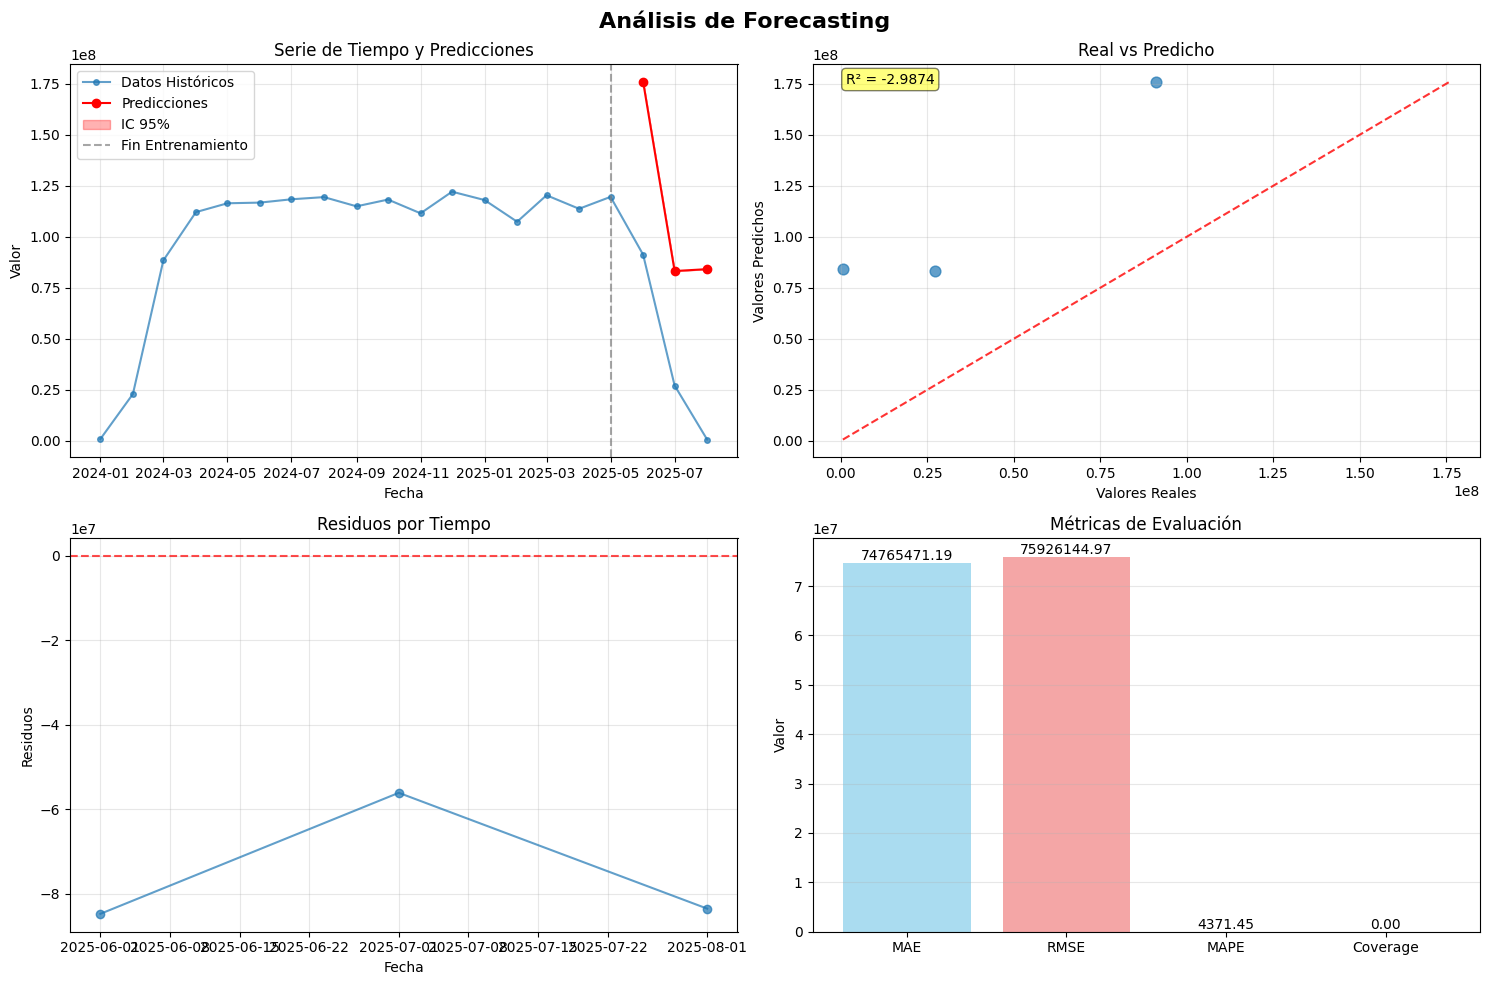

2025-06-20 19:56:25,882 - INFO - 📈 Gráficos generados exitosamente
2025-06-20 19:56:25,899 - INFO - ✅ Pipeline completado exitosamente



📊 REPORTE FINAL DE FORECASTING

📈 INFORMACIÓN DEL DATASET:
   • Total de períodos: 20
   • Rango de fechas: 2024-01-01 a 2025-08-01
   • Períodos de entrenamiento: 17
   • Períodos de prueba: 3

📊 ESTADÍSTICAS DESCRIPTIVAS:
   • Media: 93,000,793.34
   • Mediana: 114,312,923.83
   • Desviación estándar: 42,367,546.47
   • Mínimo: 651,531.75
   • Máximo: 122,089,180.90

🎯 MÉTRICAS DE EVALUACIÓN:
   • MAE (Error Absoluto Medio): 74,765,471.19
   • RMSE (Raíz Error Cuadrático Medio): 75,926,144.97
   • R² (Coeficiente de Determinación): -2.9874
   • MAPE (Error Porcentual Absoluto Medio): 4371.45%
   • Bias (Sesgo): 74,765,471.19
   • Cobertura del Intervalo de Confianza: 0.0%

🔍 INTERPRETACIÓN DE RESULTADOS:
   • Calidad del ajuste (R²): Bajo
   • Precisión del pronóstico (MAPE): Pobre
   • Confiabilidad de intervalos: Bajo

💡 RECOMENDACIONES:
   • Considerar añadir más regresores o datos externos
   • Revisar si hay patrones estacionales no capturados
   • Evaluar outliers en los datos

In [15]:
results = pipeline.run_full_pipeline()
pipeline.generate_report()